# Feature Pruning: Effect on Model Performance

This notebook evaluates whether removing low-importance features (identified via
SVD contribution + target correlation) affects XGBoost prediction performance.

**Methodology:**
1. Identify pruning candidates: features in the bottom quartile of BOTH SVD contribution and direct target correlation
2. Train XGBoost with all 39 features (baseline) using 5-fold stratified CV
3. Train XGBoost with pruned feature set (candidates removed)
4. Compare MAE and R² between baseline and pruned models

In [1]:
# Parameters cell (papermill will inject values here)
data_path = "data/features.csv"
output_dir = "data/plots/feature_pruning"

In [2]:
# Parameters
data_path = "data/features.csv"
output_dir = "data/plots/feature_pruning"


In [3]:
"""Imports and setup."""

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Ensure models package is importable
sys.path.insert(0, str(Path.cwd()))

from models.base import FEATURE_COLS, GEOMETRY_FEATURE_COLS, EXPRESSION_FEATURE_COLS

warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")
warnings.filterwarnings("ignore", category=FutureWarning)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

# Output directory
OUTPUT_DIR = Path(output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(42)
print(f"Output directory: {OUTPUT_DIR}")

Output directory: data/plots/feature_pruning


## 1. Load Data

In [4]:
"""Load feature data."""

df = pd.read_csv(data_path)
X = df[FEATURE_COLS].values
y = df["score"].values
ethnicities = df["ethnicity"].values

# Clean: drop rows with NaN or Inf
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X[mask]
y = y[mask]
ethnicities = ethnicities[mask]

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Feature columns: {len(FEATURE_COLS)}")

Samples: 17870, Features: 39
Feature columns: 39


## 2. Identify Pruning Candidates

Features are ranked by two criteria:
- **SVD contribution**: sum of squared loadings across the top-k PCA components (explaining 90% variance)
- **Direct target correlation**: |Pearson r| between each feature and the attractiveness score

Features in the bottom quartile on **both** metrics are flagged as pruning candidates.

In [5]:
"""Identify pruning candidates via SVD contribution + target correlation."""

# Standardize for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=X_scaled.shape[1])
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_90 = int(np.searchsorted(cumulative_var, 0.90)) + 1

print(f"Components for 90% variance: {n_90}")

# SVD contribution: sum of squared loadings across top-k components
loadings = pca.components_
top_loadings = loadings[:n_90]
contributions = np.sum(top_loadings**2, axis=0)
contributions_pct = contributions / contributions.sum() * 100

# Direct correlation with target
direct_corr = np.array([abs(pearsonr(X_scaled[:, i], y)[0]) for i in range(len(FEATURE_COLS))])

# Build summary
summary = pd.DataFrame({
    "feature": FEATURE_COLS,
    "svd_contribution_pct": contributions_pct,
    "direct_corr_with_target": direct_corr,
})
summary["svd_rank"] = summary["svd_contribution_pct"].rank(ascending=False).astype(int)
summary["corr_rank"] = summary["direct_corr_with_target"].rank(ascending=False).astype(int)

# Pruning candidates: bottom quartile on BOTH metrics
n_features = len(FEATURE_COLS)
drop_mask = (summary["svd_rank"] > n_features * 0.75) & (summary["corr_rank"] > n_features * 0.75)
drop_candidates = summary[drop_mask]["feature"].tolist()

# Pruned feature set
pruned_features = [f for f in FEATURE_COLS if f not in drop_candidates]
pruned_indices = [FEATURE_COLS.index(f) for f in pruned_features]

print(f"\nPruning candidates ({len(drop_candidates)} features):")
for feat in drop_candidates:
    row = summary[summary["feature"] == feat].iloc[0]
    print(f"  - {feat:<28s} SVD: {row['svd_contribution_pct']:.2f}%  |r|: {row['direct_corr_with_target']:.4f}")

print(f"\nRetained features: {len(pruned_features)} / {n_features}")

Components for 90% variance: 14



Pruning candidates (3 features):
  - nose_symmetry                SVD: 1.67%  |r|: 0.0316
  - lip_width_ratio              SVD: 1.72%  |r|: 0.0002
  - mouth_symmetry               SVD: 1.72%  |r|: 0.0090

Retained features: 36 / 39


## 3. Cross-Validation: Baseline vs. Pruned

Both models use identical XGBoost hyperparameters and 5-fold stratified CV (stratified by ethnicity).

In [6]:
"""Cross-validation helper."""

N_FOLDS = 5
VAL_FRACTION = 0.1

XGB_PARAMS = {
    "n_estimators": 1000,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "early_stopping_rounds": 50,
    "random_state": 42,
}


def run_cv(X_data, y_data, stratify_labels, label=""):
    """Run 5-fold stratified CV and return per-fold MAE and R²."""
    kf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_data, stratify_labels)):
        X_train_full, X_test = X_data[train_idx], X_data[test_idx]
        y_train_full, y_test = y_data[train_idx], y_data[test_idx]

        # Split off validation for early stopping
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=VAL_FRACTION, random_state=42
        )

        model = xgb.XGBRegressor(**XGB_PARAMS)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        r, _ = pearsonr(y_test, y_pred)

        fold_results.append({"fold": fold + 1, "mae": mae, "r2": r2, "pearson_r": r})

    results_df = pd.DataFrame(fold_results)
    mean_mae = results_df["mae"].mean()
    std_mae = results_df["mae"].std()
    mean_r2 = results_df["r2"].mean()
    std_r2 = results_df["r2"].std()
    mean_r = results_df["pearson_r"].mean()
    std_r = results_df["pearson_r"].std()

    print(f"  {label}:")
    print(f"    MAE      = {mean_mae:.4f} \u00b1 {std_mae:.4f}")
    print(f"    R\u00b2       = {mean_r2:.4f} \u00b1 {std_r2:.4f}")
    print(f"    Pearson r = {mean_r:.4f} \u00b1 {std_r:.4f}")

    return results_df

In [7]:
"""Run CV for baseline (all features) and pruned (candidates removed)."""

print(f"{'=' * 60}")
print(f"5-Fold Stratified Cross-Validation (stratified by ethnicity)")
print(f"{'=' * 60}")
print(f"XGBoost params: max_depth={XGB_PARAMS['max_depth']}, lr={XGB_PARAMS['learning_rate']}")
print()

# Baseline: all features
print(f"[Baseline] All {len(FEATURE_COLS)} features")
baseline_results = run_cv(X, y, ethnicities, label="Baseline")
print()

# Pruned: drop candidates
X_pruned = X[:, pruned_indices]
print(f"[Pruned] {len(pruned_features)} features ({len(drop_candidates)} removed)")
pruned_results = run_cv(X_pruned, y, ethnicities, label="Pruned")

5-Fold Stratified Cross-Validation (stratified by ethnicity)
XGBoost params: max_depth=6, lr=0.05

[Baseline] All 39 features


  Baseline:
    MAE      = 0.5572 ± 0.0098
    R²       = 0.4811 ± 0.0173
    Pearson r = 0.6938 ± 0.0123

[Pruned] 36 features (3 removed)


  Pruned:
    MAE      = 0.5586 ± 0.0079
    R²       = 0.4797 ± 0.0156
    Pearson r = 0.6930 ± 0.0115


## 4. Results Comparison

In [8]:
"""Compare baseline vs pruned results."""

comparison = pd.DataFrame({
    "Metric": ["MAE", "R\u00b2", "Pearson r"],
    "Baseline (mean)": [
        baseline_results["mae"].mean(),
        baseline_results["r2"].mean(),
        baseline_results["pearson_r"].mean(),
    ],
    "Baseline (std)": [
        baseline_results["mae"].std(),
        baseline_results["r2"].std(),
        baseline_results["pearson_r"].std(),
    ],
    "Pruned (mean)": [
        pruned_results["mae"].mean(),
        pruned_results["r2"].mean(),
        pruned_results["pearson_r"].mean(),
    ],
    "Pruned (std)": [
        pruned_results["mae"].std(),
        pruned_results["r2"].std(),
        pruned_results["pearson_r"].std(),
    ],
})

# Calculate delta
comparison["Delta"] = comparison["Pruned (mean)"] - comparison["Baseline (mean)"]
comparison["Delta %"] = (comparison["Delta"] / comparison["Baseline (mean)"].abs()) * 100

print("\n" + "=" * 70)
print("RESULTS: Baseline vs Pruned Feature Set")
print(f"  Baseline: {len(FEATURE_COLS)} features")
print(f"  Pruned:   {len(pruned_features)} features ({len(drop_candidates)} removed)")
print("=" * 70)
print()
print(comparison.to_string(index=False, float_format="{:.4f}".format))
print()

# Interpretation
mae_delta = comparison.loc[comparison["Metric"] == "MAE", "Delta"].values[0]
r2_delta = comparison.loc[comparison["Metric"] == "R\u00b2", "Delta"].values[0]

if abs(mae_delta) < 0.005:
    print("Conclusion: Feature pruning has NEGLIGIBLE effect on MAE (< 0.005 difference).")
elif mae_delta > 0:
    print(f"Conclusion: Feature pruning HURTS performance (MAE increased by {mae_delta:.4f}).")
else:
    print(f"Conclusion: Feature pruning IMPROVES performance (MAE decreased by {abs(mae_delta):.4f}).")

print(f"  Removed features: {drop_candidates}")


RESULTS: Baseline vs Pruned Feature Set
  Baseline: 39 features
  Pruned:   36 features (3 removed)

   Metric  Baseline (mean)  Baseline (std)  Pruned (mean)  Pruned (std)   Delta  Delta %
      MAE           0.5572          0.0098         0.5586        0.0079  0.0014   0.2491
       R²           0.4811          0.0173         0.4797        0.0156 -0.0014  -0.2810
Pearson r           0.6938          0.0123         0.6930        0.0115 -0.0009  -0.1246

Conclusion: Feature pruning has NEGLIGIBLE effect on MAE (< 0.005 difference).
  Removed features: ['nose_symmetry', 'lip_width_ratio', 'mouth_symmetry']


## 5. Visualization

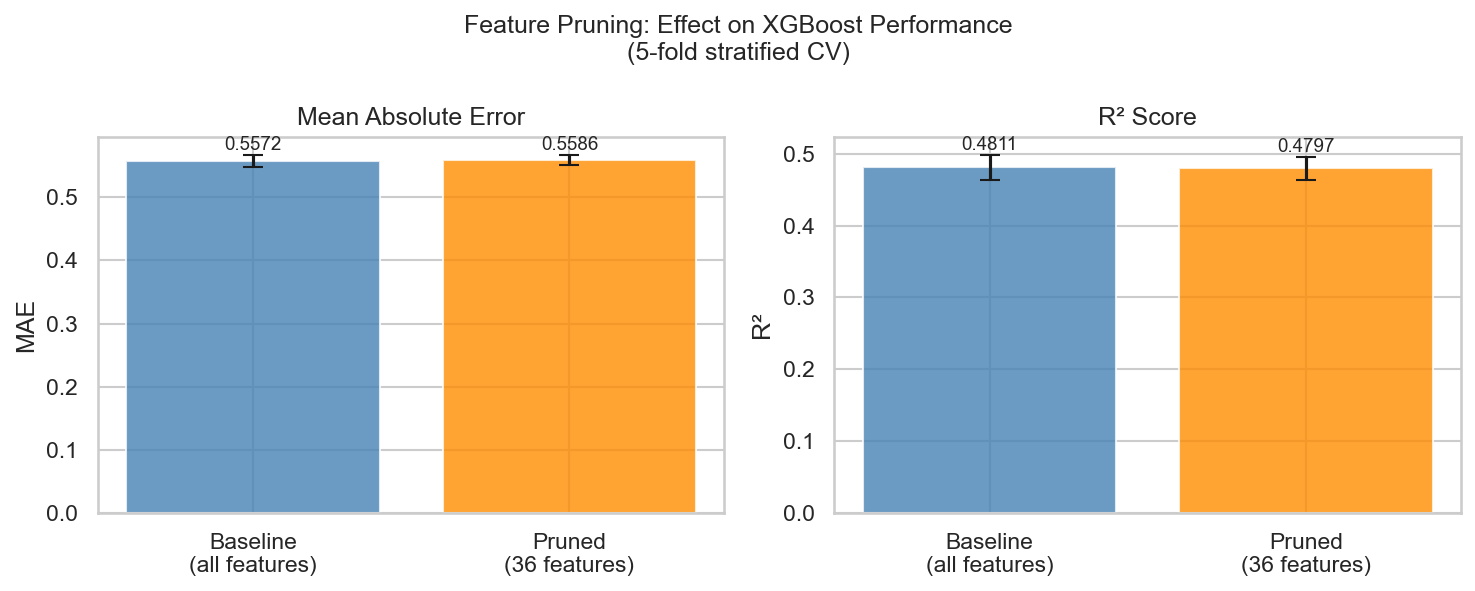

Saved: data/plots/feature_pruning/pruning_comparison.png


In [9]:
"""Bar chart comparing baseline vs pruned metrics."""

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# MAE comparison
ax = axes[0]
means = [baseline_results["mae"].mean(), pruned_results["mae"].mean()]
stds = [baseline_results["mae"].std(), pruned_results["mae"].std()]
bars = ax.bar(["Baseline\n(all features)", f"Pruned\n({len(pruned_features)} features)"],
              means, yerr=stds, capsize=5, color=["steelblue", "darkorange"], alpha=0.8)
ax.set_ylabel("MAE")
ax.set_title("Mean Absolute Error")
# Add value labels
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.002,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=9)

# R² comparison
ax = axes[1]
means = [baseline_results["r2"].mean(), pruned_results["r2"].mean()]
stds = [baseline_results["r2"].std(), pruned_results["r2"].std()]
bars = ax.bar(["Baseline\n(all features)", f"Pruned\n({len(pruned_features)} features)"],
              means, yerr=stds, capsize=5, color=["steelblue", "darkorange"], alpha=0.8)
ax.set_ylabel("R\u00b2")
ax.set_title("R\u00b2 Score")
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.002,
            f"{mean:.4f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Feature Pruning: Effect on XGBoost Performance\n(5-fold stratified CV)", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pruning_comparison.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'pruning_comparison.png'}")

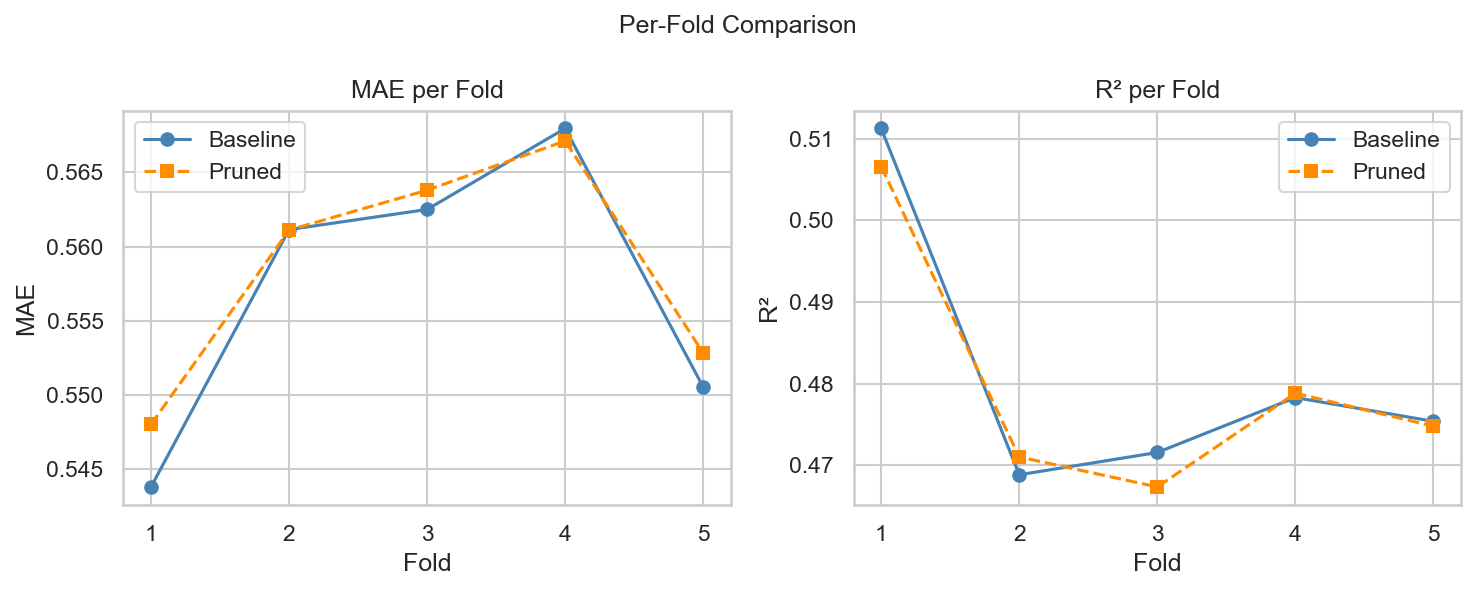

Saved: data/plots/feature_pruning/pruning_per_fold.png


In [10]:
"""Per-fold performance comparison."""

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

folds = range(1, N_FOLDS + 1)

# MAE per fold
ax = axes[0]
ax.plot(folds, baseline_results["mae"], "o-", color="steelblue", label="Baseline")
ax.plot(folds, pruned_results["mae"], "s--", color="darkorange", label="Pruned")
ax.set_xlabel("Fold")
ax.set_ylabel("MAE")
ax.set_title("MAE per Fold")
ax.legend()
ax.set_xticks(list(folds))

# R² per fold
ax = axes[1]
ax.plot(folds, baseline_results["r2"], "o-", color="steelblue", label="Baseline")
ax.plot(folds, pruned_results["r2"], "s--", color="darkorange", label="Pruned")
ax.set_xlabel("Fold")
ax.set_ylabel("R\u00b2")
ax.set_title("R\u00b2 per Fold")
ax.legend()
ax.set_xticks(list(folds))

fig.suptitle("Per-Fold Comparison", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pruning_per_fold.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'pruning_per_fold.png'}")

## 6. Feature Importance (Baseline vs. Pruned Model)

In [11]:
"""Train final models and compare feature importance."""

# Train baseline model on all data for importance analysis
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
baseline_model = xgb.XGBRegressor(**XGB_PARAMS)
baseline_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

# Train pruned model
X_pruned_train = X_train[:, pruned_indices]
X_pruned_val = X_val[:, pruned_indices]
pruned_model = xgb.XGBRegressor(**XGB_PARAMS)
pruned_model.fit(X_pruned_train, y_train, eval_set=[(X_pruned_val, y_val)], verbose=False)

# Feature importance for baseline
baseline_importances = dict(zip(FEATURE_COLS, baseline_model.feature_importances_))
pruned_importances = dict(zip(pruned_features, pruned_model.feature_importances_))

# Show top 15 features for each
print("Top 15 Feature Importances")
print("=" * 60)
print(f"{'Baseline':<30s} | {'Pruned':<30s}")
print("-" * 60)

sorted_baseline = sorted(baseline_importances.items(), key=lambda x: x[1], reverse=True)[:15]
sorted_pruned = sorted(pruned_importances.items(), key=lambda x: x[1], reverse=True)[:15]

for i in range(15):
    b_feat, b_imp = sorted_baseline[i]
    p_feat, p_imp = sorted_pruned[i] if i < len(sorted_pruned) else ("-", 0)
    print(f"  {b_feat:<22s} {b_imp:.4f} | {p_feat:<22s} {p_imp:.4f}")

Top 15 Feature Importances
Baseline                       | Pruned                        
------------------------------------------------------------
  eye_area_ratio         0.1341 | eye_area_ratio         0.1809
  eye_width_ratio        0.0642 | nose_width_ratio       0.0594
  nose_width_ratio       0.0594 | eye_width_ratio        0.0510
  mouth_chin_ratio       0.0508 | mouth_chin_ratio       0.0494
  eye_height_ratio       0.0352 | expr_smile             0.0375
  expr_smile             0.0331 | jaw_width_ratio        0.0345
  jaw_width_ratio        0.0321 | lip_fullness_ratio     0.0300
  chin_taper             0.0312 | chin_taper             0.0291
  lip_fullness_ratio     0.0304 | gonial_angle           0.0278
  expr_eye_wide          0.0255 | nose_length_ratio      0.0255
  gonial_angle           0.0251 | expr_eye_wide          0.0251
  nose_length_ratio      0.0236 | phi_deviation          0.0249
  phi_deviation          0.0233 | expr_brow_down         0.0238
  expr_brow_down

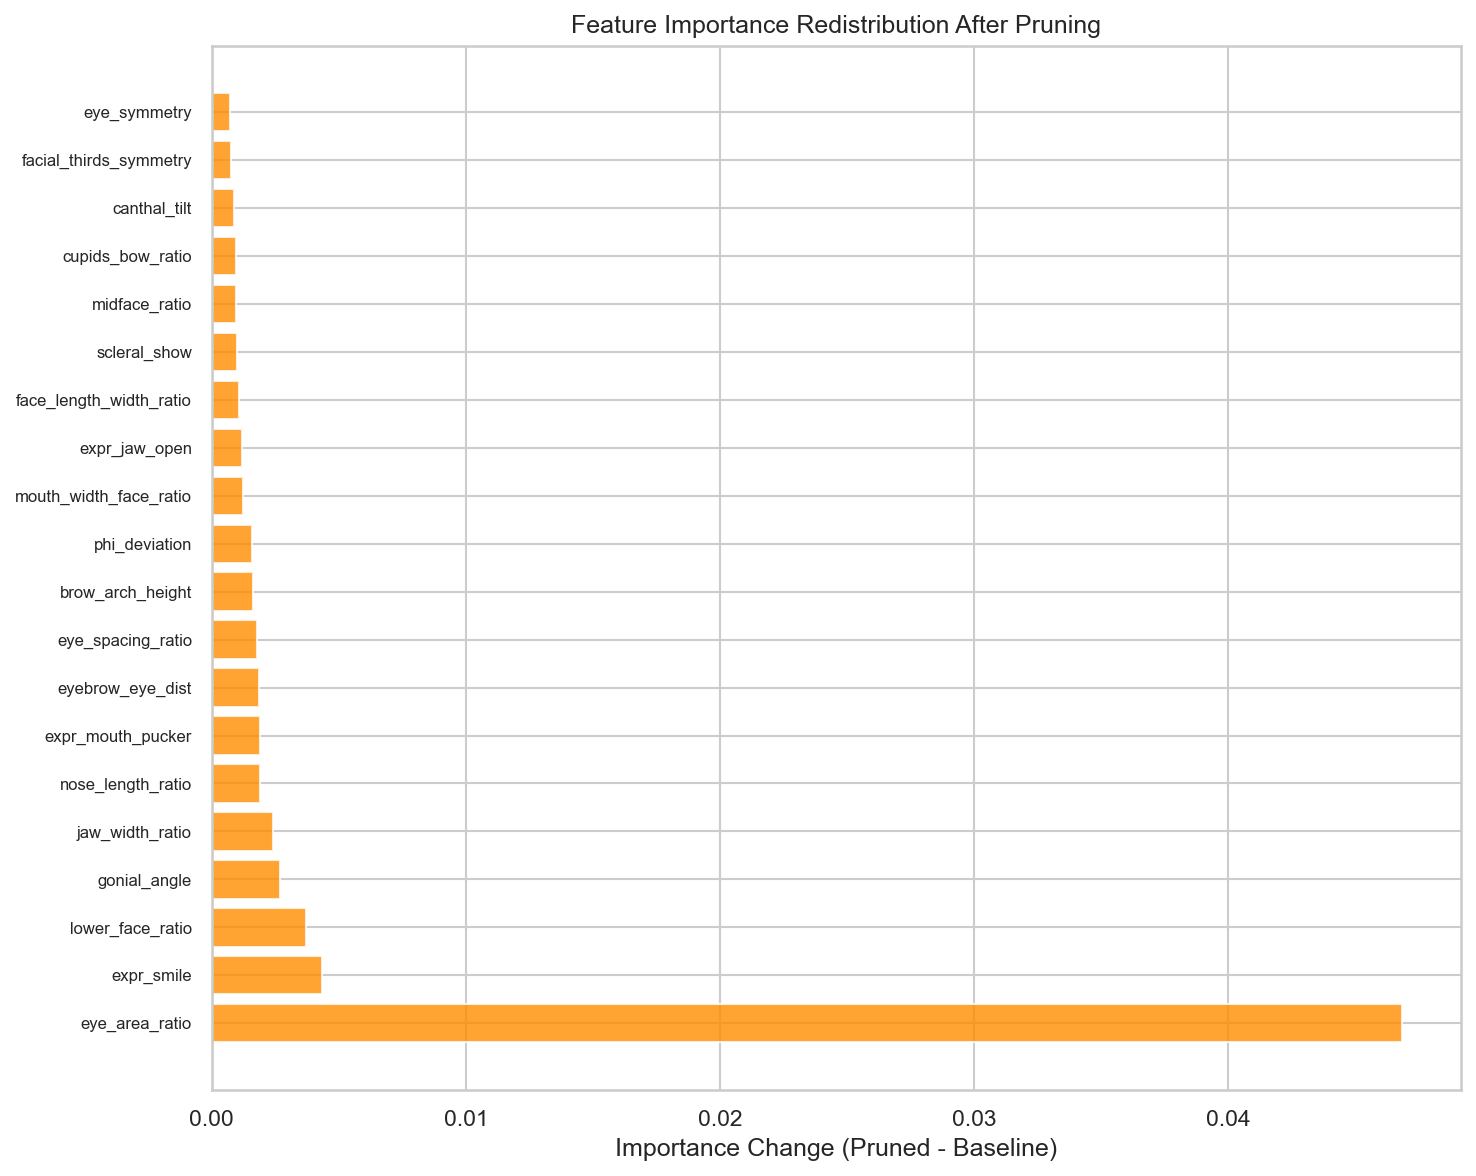

Saved: data/plots/feature_pruning/importance_redistribution.png


In [12]:
"""Importance redistribution: where does the importance of dropped features go?"""

# For features that exist in both, compare their importance
shared_features = [f for f in pruned_features if f in baseline_importances]

baseline_shared = np.array([baseline_importances[f] for f in shared_features])
pruned_shared = np.array([pruned_importances[f] for f in shared_features])

# Sort by biggest increase in importance
delta_importance = pruned_shared - baseline_shared
sort_idx = np.argsort(delta_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(shared_features))
top_idx = sort_idx[:top_n]

y_pos = range(top_n)
ax.barh(y_pos, delta_importance[top_idx], color=["darkorange" if d > 0 else "steelblue" for d in delta_importance[top_idx]], alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels([shared_features[i] for i in top_idx], fontsize=8)
ax.set_xlabel("Importance Change (Pruned - Baseline)")
ax.set_title("Feature Importance Redistribution After Pruning")
ax.axvline(0, color="black", linewidth=0.5)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "importance_redistribution.png")
plt.show()
print(f"Saved: {OUTPUT_DIR / 'importance_redistribution.png'}")

## 7. Summary

In [13]:
"""Print final summary."""

print("\n" + "=" * 70)
print("FEATURE PRUNING ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nDataset: {len(y)} samples")
print(f"Model: XGBoost (max_depth={XGB_PARAMS['max_depth']}, lr={XGB_PARAMS['learning_rate']})")
print(f"Evaluation: {N_FOLDS}-fold stratified CV (stratified by ethnicity)")
print(f"\nFeature sets:")
print(f"  Baseline: {len(FEATURE_COLS)} features (all geometry + expression)")
print(f"  Pruned:   {len(pruned_features)} features ({len(drop_candidates)} dropped)")
print(f"\nDropped features: {drop_candidates}")
print(f"\nResults:")
print(f"  {'Metric':<12s} {'Baseline':>12s} {'Pruned':>12s} {'Delta':>10s}")
print(f"  {'-' * 50}")

for _, row in comparison.iterrows():
    baseline_str = f"{row['Baseline (mean)']:.4f} \u00b1 {row['Baseline (std)']:.4f}"
    pruned_str = f"{row['Pruned (mean)']:.4f} \u00b1 {row['Pruned (std)']:.4f}"
    delta_str = f"{row['Delta']:+.4f}"
    print(f"  {row['Metric']:<12s} {baseline_str:>20s} {pruned_str:>20s} {delta_str:>10s}")

print(f"\nPlots saved to: {OUTPUT_DIR}/")
print("=" * 70)


FEATURE PRUNING ANALYSIS SUMMARY

Dataset: 17870 samples
Model: XGBoost (max_depth=6, lr=0.05)
Evaluation: 5-fold stratified CV (stratified by ethnicity)

Feature sets:
  Baseline: 39 features (all geometry + expression)
  Pruned:   36 features (3 dropped)

Dropped features: ['nose_symmetry', 'lip_width_ratio', 'mouth_symmetry']

Results:
  Metric           Baseline       Pruned      Delta
  --------------------------------------------------
  MAE               0.5572 ± 0.0098      0.5586 ± 0.0079    +0.0014
  R²                0.4811 ± 0.0173      0.4797 ± 0.0156    -0.0014
  Pearson r         0.6938 ± 0.0123      0.6930 ± 0.0115    -0.0009

Plots saved to: data/plots/feature_pruning/
